In [2]:
import os
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
# data download - tf에서 권장하는 방법
# with_info=True : dataset info()를 반환
# as_supervised=True : data를 (image, label)형태로 반환
(dataset, info) = tfds.load('rock_paper_scissors', with_info=True, as_supervised=True)
print(dataset)
print(info)

{'train': <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>, 'test': <_PrefetchDataset element_spec=(TensorSpec(shape=(300, 300, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}
tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/root/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test

label ClassLabel(shape=(), dtype=int64, num_classes=3)
label_name ['rock', 'paper', 'scissors']
dict_keys(['train', 'test'])
(300, 300, 3) <dtype: 'uint8'>
2


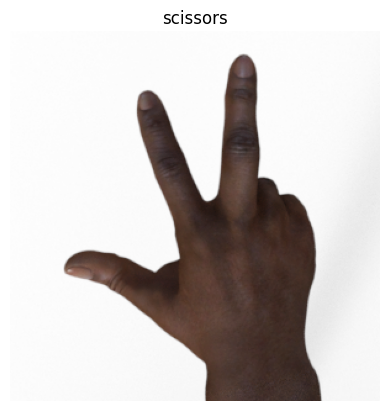

In [28]:
label_names = info.features['label'].names
print('label', info.features['label']) # (shape=(), dtype=int64, num_classes=3)
print('label_name', label_names) # ['rock', 'paper', 'scissors']
print(dataset.keys()) # [Split('train'), Split('test')]

for image, label in dataset['train'].skip(0).take(1): # 몇번째, 몇개
  print(image.shape, image.dtype)
  print(label.numpy()) # 1
  plt.imshow(image)
  plt.title(label_names[label.numpy()])
  plt.axis('off')
  plt.show()


In [5]:
# 폴더(디렉토리) 구조를 생성
# 이미지 root 폴더
base_dir = './rock_paper_scissors_filtered'

# train data 만들 폴더 - 학습을 위한 이미지 폴더
train_dir = os.path.join(base_dir, 'train')

# validation data 만들 폴더 - 검증을 위한 이미지 폴더
validation_dir = os.path.join(base_dir, 'validation')

# test data 만들 폴더 - 검증을 위한 이미지 폴더
test_dir = os.path.join(base_dir, 'test')

# train폴더 안에 rock / paper / scissors 나누기
train_rock_dir = os.path.join(train_dir, 'rock')
train_paper_dir = os.path.join(train_dir, 'paper')
train_scissors_dir = os.path.join(train_dir, 'scissors')

# validation 폴더 안에 rock / paper / scissors 나누기
val_rock_dir = os.path.join(validation_dir, 'rock')
val_paper_dir = os.path.join(validation_dir, 'paper')
val_scissors_dir = os.path.join(validation_dir, 'scissors')

# test 폴더 안에 rock / paper / scissors 나누기
test_rock_dir = os.path.join(test_dir, 'rock')
test_paper_dir = os.path.join(test_dir, 'paper')
test_scissors_dir = os.path.join(test_dir, 'scissors')


# 폴더(디렉토리)가 없을때 생성
for d in [train_rock_dir, train_paper_dir, train_scissors_dir, val_rock_dir, val_paper_dir, val_scissors_dir, test_rock_dir, test_paper_dir, test_scissors_dir]:
  os.makedirs(d, exist_ok=True)

In [6]:
# train data의 일부를 validation으로 사용 (8:2)
total_train = info.splits['train'].num_examples # 전체 갯수 확인
total_test = info.splits['test'].num_examples # 전체 갯수 확인
print(total_train, total_test, total_train + total_test) # 2520 372 2892
train_size = int(0.8 * total_train)
print(train_size) # 2016

2520 372 2892
2016


In [7]:
# train / validation 분할 + 이미지 저장
IMG_SIZE = (150, 150)

def save_imageFunc(img, label, idx, split):

  # 이미지 크기 조정
  img = tf.image.resize(img, IMG_SIZE)
  # tensor를 정수형 이미지로 변환해 numpy 배열로 반환
  # ex) 0.12 -> 0, 255.0 -> 255
  img = tf.cast(img, tf.uint8).numpy()

  # 폴더 경로 정해주기
  if split == 'train':
    if label == 0:
      folder = train_rock_dir
    elif label == 1:
      folder = train_paper_dir
    else:
      folder = train_scissors_dir

  elif split == 'val':
    if label == 0:
      folder = val_rock_dir
    elif label == 1:
      folder = val_paper_dir
    else:
      folder = val_scissors_dir

  else:
    if label == 0:
      folder = test_rock_dir
    elif label == 1:
      folder = test_paper_dir
    else:
      folder = test_scissors_dir

  path = os.path.join(folder, f'{idx}.jpg') # 이미지 저장 경로
  # 이미지 저장
  tf.keras.preprocessing.image.save_img(path, img) # 이미지가 해당 경로에 저장

for i , (img, label) in enumerate(dataset['train']):
  if i < train_size:
    save_imageFunc(img, label, i, 'train')
  else:
    save_imageFunc(img, label, i, 'val')

for i , (img, label) in enumerate(dataset['test']):
  save_imageFunc(img, label, i, 'test')

print('데이터 준비 완료')

데이터 준비 완료


In [8]:
base_dir = './rock_paper_scissors_filtered'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# train폴더 안에 rock / paper / scissors 나누기
train_rock_dir = os.path.join(train_dir, 'rock')
train_paper_dir = os.path.join(train_dir, 'paper')
train_scissors_dir = os.path.join(train_dir, 'scissors')

# validation 폴더 안에 rock / paper / scissors 나누기
val_rock_dir = os.path.join(validation_dir, 'rock')
val_paper_dir = os.path.join(validation_dir, 'paper')
val_scissors_dir = os.path.join(validation_dir, 'scissors')

# test 폴더 안에 rock / paper / scissors 나누기
test_rock_dir = os.path.join(test_dir, 'rock')
test_paper_dir = os.path.join(test_dir, 'paper')
test_scissors_dir = os.path.join(test_dir, 'scissors')

# 디렉토리 경로 유무 확인
for p in [train_rock_dir, train_paper_dir, train_scissors_dir, val_rock_dir, val_paper_dir, val_scissors_dir, test_rock_dir, test_paper_dir, test_scissors_dir]:
  print(p, ' -> ', os.path.exists(p))

# 데이터 비율 확인하기 - 분포 확인
print('rock(train): ', len(os.listdir(train_rock_dir)))
print('paper(train): ', len(os.listdir(train_paper_dir)))
print('scissors(train): ', len(os.listdir(train_scissors_dir)))
print('rock(val): ', len(os.listdir(val_rock_dir)))
print('paper(val): ', len(os.listdir(val_paper_dir)))
print('scissors(val): ', len(os.listdir(val_scissors_dir)))
print('rock(test): ', len(os.listdir(test_rock_dir)))
print('paper(test): ', len(os.listdir(test_paper_dir)))
print('scissors(test): ', len(os.listdir(test_scissors_dir)))
# rock(train)     :  664
# paper(train)    :  683
# scissors(train) :  669
# rock(val)       :  176
# paper(val)      :  157
# scissors(val)   :  171
# rock(test)      :  124
# paper(test)     :  124
# scissors(test)  :  124


./rock_paper_scissors_filtered/train/rock  ->  True
./rock_paper_scissors_filtered/train/paper  ->  True
./rock_paper_scissors_filtered/train/scissors  ->  True
./rock_paper_scissors_filtered/validation/rock  ->  True
./rock_paper_scissors_filtered/validation/paper  ->  True
./rock_paper_scissors_filtered/validation/scissors  ->  True
./rock_paper_scissors_filtered/test/rock  ->  True
./rock_paper_scissors_filtered/test/paper  ->  True
./rock_paper_scissors_filtered/test/scissors  ->  True
rock(train):  664
paper(train):  683
scissors(train):  669
rock(val):  176
paper(val):  157
scissors(val):  171
rock(test):  124
paper(test):  124
scissors(test):  124


In [9]:
# Colab에서 폴더 전체를 내PC로 다운로드하기
import shutil
from google.colab import files

shutil.make_archive(
          'rock_paper_scissors_filtered',   # 생성될 zip 파일 이름
          'zip',                      # 압축 형식
          './rock_paper_scissors_filtered'  # 압축할 폴더명
)

files.download('rock_paper_scissors_filtered.zip') # 내 PC로 다운로드

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
IMG_SIZE = (224, 224)   # 필요에 따라 (128,128) 등으로 변경
BATCH    = 32

In [11]:
IMG_HEIGHT, IMG_WIDTH = 150, 150
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 128
EPOCHS = 10

# 1. 증강 전 데이터 생성기
plain_datagen = ImageDataGenerator(
    rescale=1./255
)

# 2. 증강 후 데이터 생성기
augment_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# 3. 검증/테스트용 생성기
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# 4. 증강 전 train data
train_data_plain = plain_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",   # 원-핫 인코딩
    shuffle=True,
    seed=42
)

# 5. 증강 후 train data
train_data_aug = augment_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",   # 원-핫 인코딩
    shuffle=True,
    seed=42
)

# 6. validation data
val_data = val_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# 7. test data
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# 8. 클래스 이름 확인
class_names = list(train_data_plain.class_indices.keys())

print("class_indices:", train_data_plain.class_indices)
print("class_names:", class_names)

Found 2016 images belonging to 3 classes.
Found 2016 images belonging to 3 classes.
Found 504 images belonging to 3 classes.
Found 372 images belonging to 3 classes.
class_indices: {'paper': 0, 'rock': 1, 'scissors': 2}
class_names: ['paper', 'rock', 'scissors']


In [12]:
images, labels = next(train_data_plain)

print("증강 전 images shape:", images.shape)
print("증강 전 labels shape:", labels.shape)

print("image min:", images.min())
print("image max:", images.max())

print("labels first 5:")
print(labels[:5])

증강 전 images shape: (128, 150, 150, 3)
증강 전 labels shape: (128, 3)
image min: 0.0
image max: 1.0
labels first 5:
[[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [13]:
images, labels = next(train_data_aug)

print("증강 후 images shape:", images.shape)
print("증강 후 labels shape:", labels.shape)

print("image min:", images.min())
print("image max:", images.max())

print("labels first 5:")
print(labels[:5])

증강 후 images shape: (128, 150, 150, 3)
증강 후 labels shape: (128, 3)
image min: 0.0
image max: 1.0
labels first 5:
[[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [14]:
# 증강 전 모델 생성
plain_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

plain_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(plain_model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
# 증강 후 모델 생성
aug_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

aug_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(aug_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
# 모델 검정하기
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)
history = plain_model.fit(
    train_data_plain,
    epochs=EPOCHS,
    validation_data=val_data,
    verbose=1,
    callbacks=[early_stopping]
)
print(f'loss: {history.history["loss"][-1]}')
print(f'val_loss: {history.history["val_loss"][-1]}')
print(f'accuracy: {history.history["accuracy"][-1]}')
print(f'val_accuracy: {history.history["val_accuracy"][-1]}')


history_aug = aug_model.fit(
    train_data_aug,
    epochs=EPOCHS,
    validation_data=val_data,
    verbose=1,
    callbacks=[early_stopping]
)
print(f'aug_loss: {history_aug.history["loss"][-1]}')
print(f'aug_val_loss: {history_aug.history["val_loss"][-1]}')
print(f'aug_accuracy: {history_aug.history["accuracy"][-1]}')
print(f'aug_val_accuracy: {history_aug.history["val_accuracy"][-1]}')

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 100s 6s/step - accuracy: 0.5813 - loss: 1.1148 - val_accuracy: 0.8075 - val_loss: 0.4719
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 147s 7s/step - accuracy: 0.9306 - loss: 0.2120 - val_accuracy: 0.9901 - val_loss: 0.0320
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.9945 - loss: 0.0233 - val_accuracy: 0.9980 - val_loss: 0.0148
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.9975 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 8.0783e-04
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 95s 6s/step - accuracy: 1.0000 - loss: 3.1687e-04 - val_accuracy: 1.0000 - val_loss: 3.1852e-04
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 92s 6s/step - accuracy: 1.0000 - loss: 2.2152e-04 - val_accuracy: 1.0000 - val_loss: 3.2309e-04
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 152s 6s/step - accuracy: 1.0000 - loss: 1.5895e-04 - val_a

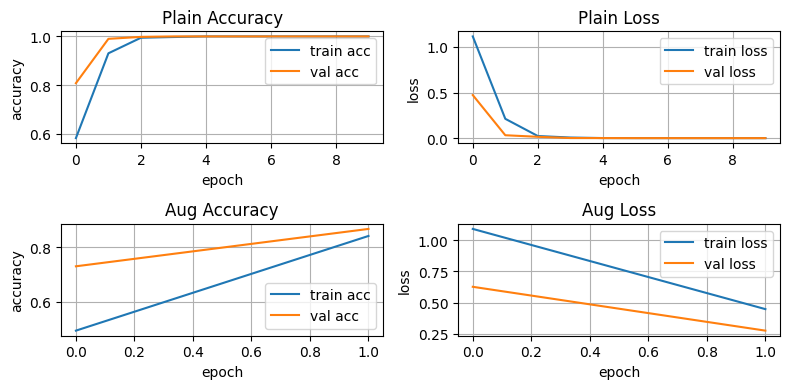

In [30]:
# 학습 곡선 시각화
plt.figure(figsize=(8, 4))
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Plain Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Plain Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(history_aug.history['accuracy'], label='train acc')
plt.plot(history_aug.history['val_accuracy'], label='val acc')
plt.title('Aug Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(history_aug.history['loss'], label='train loss')
plt.plot(history_aug.history['val_loss'], label='val loss')
plt.title('Aug Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step


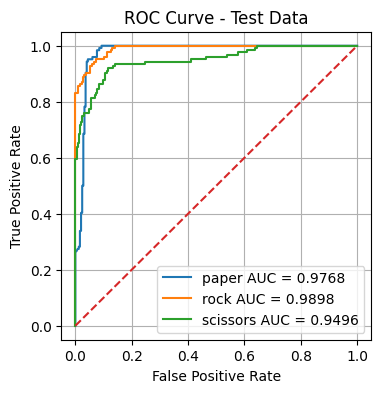

In [31]:
# ROC Curve 검정
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = len(class_names)

y_true_int = test_data.classes
y_true_onehot = to_categorical(y_true_int, num_classes=NUM_CLASSES)

y_pred_prob = plain_model.predict(test_data)

plt.figure(figsize=(4, 4))

for i in range(NUM_CLASSES):
    fpr, tpr, thresholds = roc_curve(
        y_true_onehot[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} AUC = {roc_auc:.4f}'
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Data')
plt.legend()
plt.grid()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step


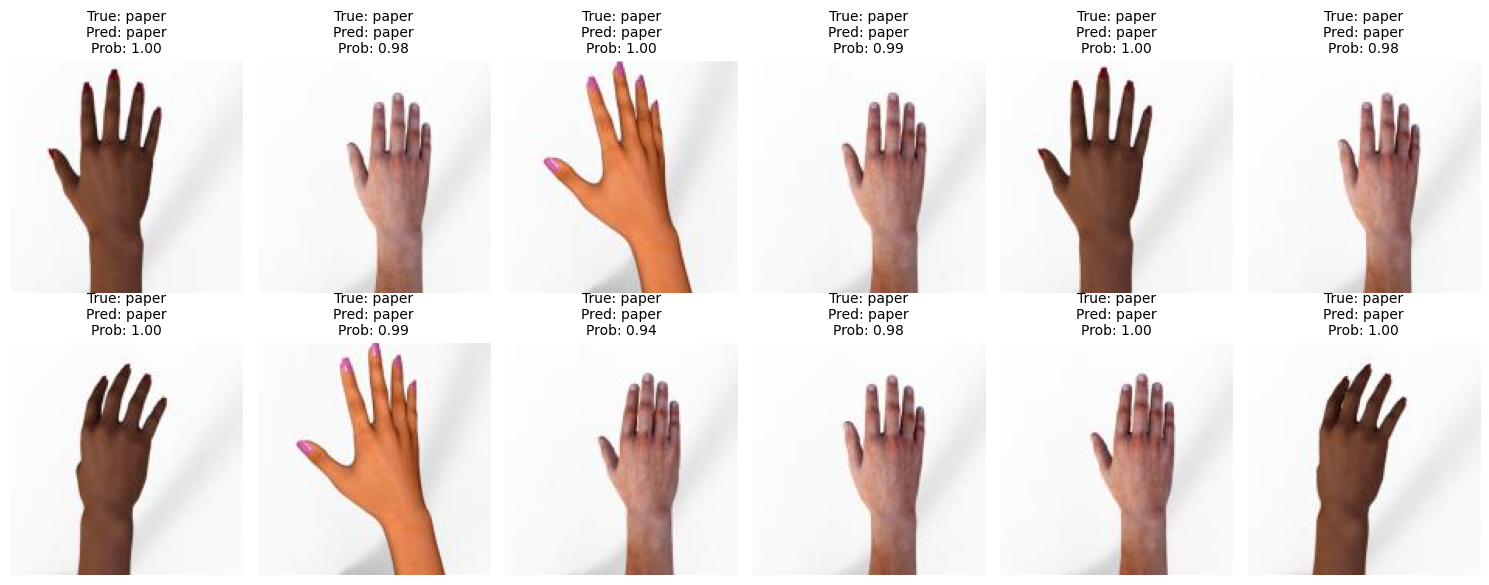

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# test 데이터 예측
y_pred_prob = plain_model.predict(test_data)

# 예측 클래스 index
y_pred = np.argmax(y_pred_prob, axis=1)

# 실제 클래스 index
y_true = test_data.classes

# 클래스 이름
class_names = list(test_data.class_indices.keys())

# 파일 경로
file_paths = test_data.filepaths

# 보여줄 이미지 개수
n_show = 12
cols = 6
rows = int(np.ceil(n_show / cols))

plt.figure(figsize=(15, rows * 3))

for i in range(n_show):
    img_path = file_paths[i]

    # 이미지 로드
    img = image.load_img(
        img_path,
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(img)
    ax.axis("off")

    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    pred_prob = np.max(y_pred_prob[i])

    # 정답 여부
    is_correct = y_true[i] == y_pred[i]

    # 정답이면 black, 틀리면 red
    title_color = "black" if is_correct else "red"

    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}\nProb: {pred_prob:.2f}",
        color=title_color,
        fontsize=10
    )

plt.tight_layout()
plt.show()